<font size = '4'>  In this section, we create a **Monte Carlo Simulation** using **NumPy Vectorization** to estimate the **fair value** of a european call option by generating **100,000 random potential future stock price paths** that the stock can take based on the **Black-Scholes-Merton (BSM) geometric brownian motion model**. </font>

In [2]:
import math
import numpy as np

In [3]:
S0 = 100
K = 105.
T = 1.0
r = 0.05
sigma = 0.2

In [4]:
I = 100000

In [5]:
np.random.seed(1000)

In [6]:
z = np.random.standard_normal(I)

In [7]:
ST = S0 * np.exp((r - sigma ** 2 / 2) * T + sigma * math.sqrt(T) * z)

In [8]:
hT = np.maximum(ST - K, 0)

In [9]:
C0 = math.exp(-r * T) * np.mean(hT)

In [10]:
print('Value of the European call option: {:5.3f}.'.format(C0))

Value of the European call option: 8.019.


<font size='4'> The simulation produced a value of **8.019**, which matches the **theoretical BSM model expectations** for an at-the-money-forward call option. 
- Convergence: with **I = 100,000 iterations**, the law of large numbers ensures our Monte Carlo Simulations converges to the **true analytical value**. </font>

In [14]:
import numpy as np
import pandas as pd
from pylab import plt, mpl

<font size=4> In this section, we retrieve historical index data about the **S&P500** to evaluate **market risk**. We calculate the **annualized rolling standard deviation** of log returns (**realized volalitility**) using a vectorized approach for computational efficency. By plotting the index price alongside it's volatility, we can visualize the the **inverse relationship** often seen in equity markets, where **sharp price** declines typically correspong with **volatility spikes**.</font>

In [15]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [16]:
url = 'http://hilpisch.com/tr_eikon_eod_data.csv'
data = pd.read_csv(url, index_col=0, parse_dates=True)
data = pd.DataFrame(data['.SPX'])
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .SPX    2138 non-null   float64
dtypes: float64(1)
memory usage: 33.4 KB


In [25]:
data['rets'] = np.log(data['.SPX'] / data['.SPX'].shift(1))
data['vola'] = data['rets'].rolling(252).std() * np.sqrt(252)
data.dropna(inplace=True)
data.tail()

,.SPX,rets,vola
Date,,,
2018-06-25,2717.07,-0.013820,0.125021
2018-06-26,2723.06,0.002202,0.125034
2018-06-27,2699.63,-0.008642,0.125072
2018-06-28,2716.31,0.006160,0.124924
2018-06-29,2718.37,0.000758,0.124593


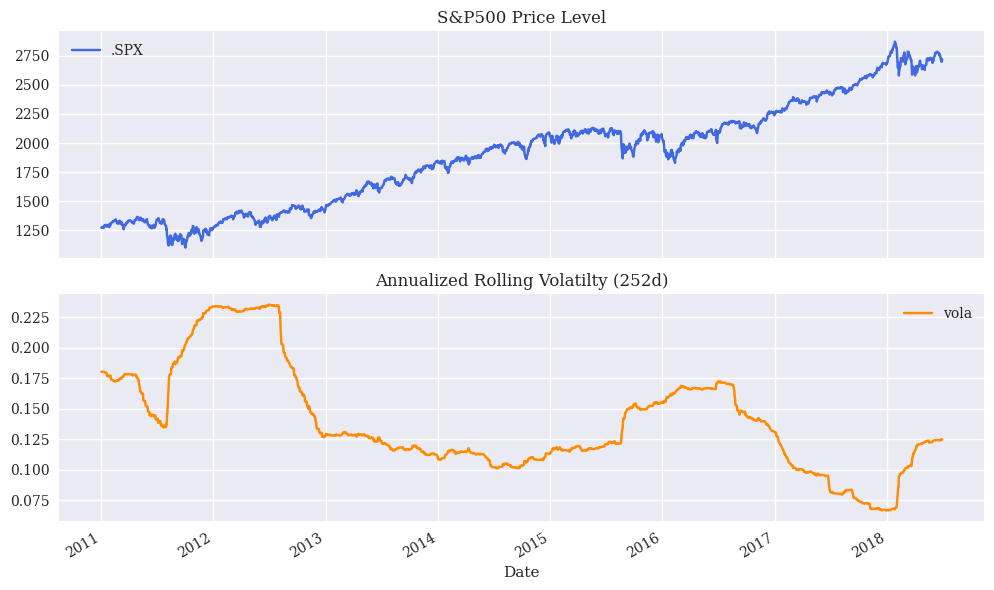

In [33]:
plt.close('all')

data[['.SPX', 'vola']].plot(subplots=True, figsize=(10,6), color=['royalblue','darkorange'], grid=True, title=['S&P500 Price Level', 'Annualized Rolling Volatilty (252d)'])
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


In [35]:
import numpy as np
import pandas as pd

<font size=4> In this section, we transition from market-level analysis to active strategy development using a **Support Vector Machine (SVM) classifier**. The model utilizes **6 days of historical log returns** as predictive features to forecast market direction for Apple Inc. (**AAPL.O**). We compare the performance of this **algorithmic long/short strategy** against a passive "**buy and hold" benchmark** over an 8-year horizon. By visualizing the acculalitive growth of $1, we can evaluate the model's ability to **capture alpha** and outperform the underlying equity through varying market regimes.</font>

In [ ]:
url = 'http://hilpisch.com/tr_eikon_eod_data.csv'
data = pd.read_csv(url, index_col=0, parse_dates=True)
data = pd.DataFrame(data['AAPL.O'])
data['Returns'] = np.log(data['AAPL.O'] / data['AAPL.O'].shift(1))
data.dropna(inplace=True)
data.head()

In [40]:
lags = 6

In [41]:
cols = []
for lag in range(1, lags + 1):
    col = 'lag_{}'.format(lag)
    data[col] = np.sign(data['Returns'].shift(lag))
    cols.append(col)
data.dropna(inplace=True)

In [42]:
from sklearn.svm import SVC

In [43]:
model = SVC(gamma='auto')

In [45]:
model.fit(data[cols], np.sign(data['Returns']))

SVC(gamma='auto')

In [46]:
SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0, decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf',max_iter=-1, probability=False, random_state=None, shrinking=True, tol=0.001, verbose=False)

SVC(gamma='auto')

In [47]:
data['Prediction'] = model.predict(data[cols])

In [49]:
data['Strategy'] = data['Prediction'] * data['Returns']

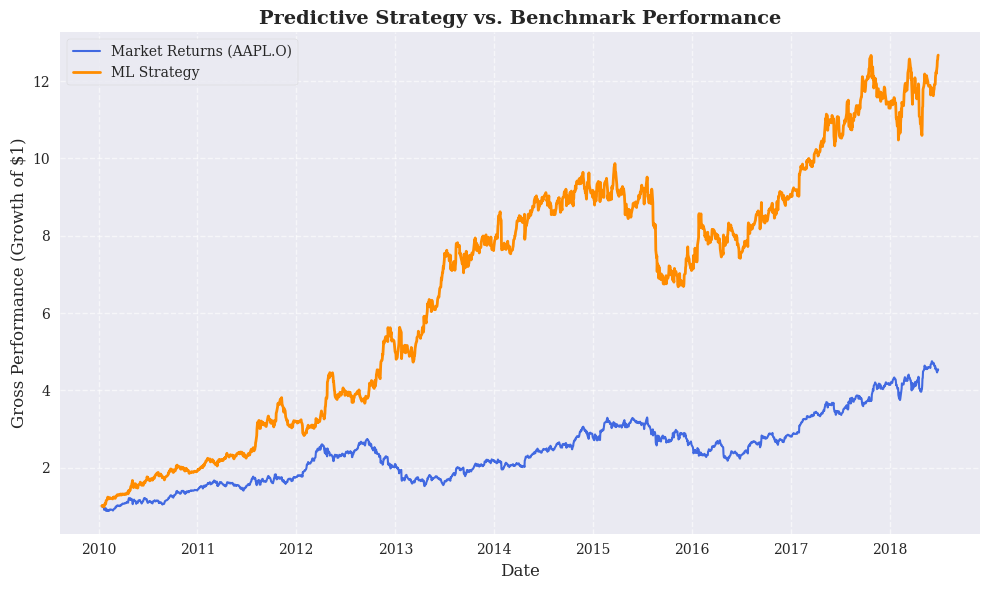

In [57]:
plt.close('all')

perf_data = data[['Returns','Strategy']].cumsum().apply(np.exp)
plt.figure(figsize=(10,6))
plt.plot(perf_data['Returns'], label='Market Returns (AAPL.O)', color='royalblue', lw=1.5)
plt.plot(perf_data['Strategy'], label='ML Strategy', color='darkorange', lw=2)

plt.title('Predictive Strategy vs. Benchmark Performance', fontsize=14, fontweight='bold', family='serif')
plt.xlabel('Date', fontsize=12, family='serif')
plt.ylabel('Gross Performance (Growth of $1)', fontsize=12, family='serif')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()